Loading dataset...
Data loaded: (40, 30, 224, 224, 3)
Loading MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step
Extracting features...
Feature shape: (40, 30, 1280)


c:\Users\ACER\violence_detection\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,794 (2.78 MB)

 Trainable params: 729,794 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

Training model...
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7500 - loss: 0.4174 - val_accuracy: 0.1250 - val_loss: 1.4361
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9375 - loss: 0.1551 - val_accuracy: 0.1250 - val_loss: 2.3935
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0543 - val_accuracy: 0.1250 - val_loss: 1.7040
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9375 - loss: 0.0760 - val_accuracy: 0.1250 - val_loss: 2.0577
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0232 - val_accuracy: 0.1250 - val_loss: 2.9460


Model saved!


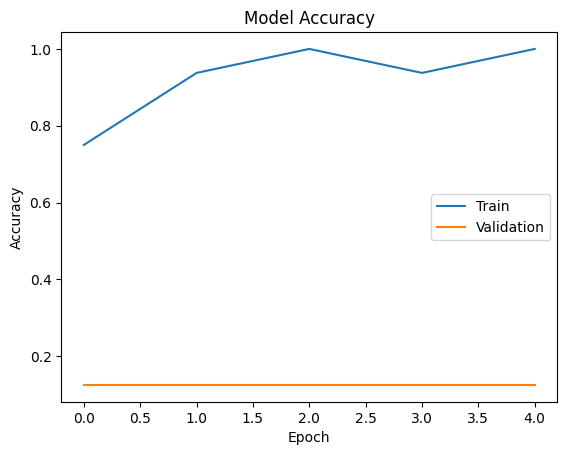

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ----------------------------
# CONFIG
# ----------------------------
DATASET_PATH = "dataset"
IMG_SIZE = 224
SEQUENCE_LENGTH = 30
LIMIT = 20   # use small data first
EPOCHS = 5
BATCH_SIZE = 4

classes = ["non_violence", "violence"]

# ----------------------------
# FRAME EXTRACTION
# ----------------------------
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < SEQUENCE_LENGTH:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame / 255.0
        frames.append(frame)

    cap.release()

    # padding if less frames
    while len(frames) < SEQUENCE_LENGTH:
        frames.append(frames[-1])

    return np.array(frames)

# ----------------------------
# LOAD DATASET
# ----------------------------
X, y = [], []

print("Loading dataset...")

for label, class_name in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, class_name)

    for i, video in enumerate(os.listdir(class_path)):
        if i >= LIMIT:
            break

        video_path = os.path.join(class_path, video)

        try:
            frames = extract_frames(video_path)
            X.append(frames)
            y.append(label)
        except:
            print(f"Error reading {video_path}")

X = np.array(X)
y = to_categorical(y)

print("Data loaded:", X.shape)

# ----------------------------
# FEATURE EXTRACTION (CNN)
# ----------------------------
print("Loading MobileNetV2...")

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

def extract_features(dataset):
    features = []

    for video in dataset:
        video_features = []

        for frame in video:
            frame = np.expand_dims(frame, axis=0)
            feature = base_model.predict(frame, verbose=0)
            video_features.append(feature.flatten())

        features.append(video_features)

    return np.array(features)

print("Extracting features...")
X_features = extract_features(X)

print("Feature shape:", X_features.shape)

# ----------------------------
# LSTM MODEL
# ----------------------------
model = Sequential()

model.add(LSTM(128, input_shape=(SEQUENCE_LENGTH, 1280)))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# ----------------------------
# TRAIN
# ----------------------------
print("Training model...")

history = model.fit(
    X_features,
    y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2
)

# ----------------------------
# SAVE MODEL
# ----------------------------
os.makedirs("model", exist_ok=True)
model.save("model/violence_model.h5")

print("Model saved!")

# ----------------------------
# PLOT ACCURACY
# ----------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()